In [23]:
import pandas as pd

# If regression_logistic is a local module, add its parent directory to sys.path
import sys
sys.path.append('/home/akef/Documents/ml-from-scratch/regression_logistic')

from src.logistic_regression import LogisticRegression as LogReg

# Loading Data

In [24]:
# Load dataset
data = pd.read_csv('../../data/diabetes.csv')

# Uncomment to see data description
#print(data.describe())
#print(data.columns.to_list())

# Plot the data
X = data.drop(columns=['Outcome'])
Y = data['Outcome']
# Visualize the relationship between each feature and the target variable
# Here, we will create scatter plots for each feature against the target variable
'''
for i in range(X_train.shape[1]):
    plt.figure()
    plt.scatter(X_train.iloc[:, i].values, Y_train.values, color='blue', alpha=0.5)
    plt.xlabel(X_train.columns[i])
    plt.ylabel('Outcome')
    plt.title(f'{X_train.columns[i]} vs Outcome')
    plt.show()
'''    

"\nfor i in range(X_train.shape[1]):\n    plt.figure()\n    plt.scatter(X_train.iloc[:, i].values, Y_train.values, color='blue', alpha=0.5)\n    plt.xlabel(X_train.columns[i])\n    plt.ylabel('Outcome')\n    plt.title(f'{X_train.columns[i]} vs Outcome')\n    plt.show()\n"

In [25]:
# Splitting dataset into training and testing set
LogRegModel = LogReg()
training_size = int(data.shape[0] * 0.75)
test_size = data.shape[0] - training_size
X_train = X.head(training_size).to_numpy() 
Y_train = Y.head(training_size).to_numpy()

X_test = X.tail(int(test_size)).to_numpy()  
Y_test = Y.tail(int(test_size)).to_numpy()

# Gradient Descent Algorithm
  For further understanding of the mathematical background behind it consult the docs/gradient_descent_theory.pdf file

In [26]:
def metrics(Model, X_train, Y_train, X_test, Y_test):
    # Accuracy
    Y_pred = Model.predict(X_train)
    print("Training accuracy: ", Model.accuracy(Y_train, Y_pred))
    Y_pred = Model.predict(X_test)
    print("Testing accuracy: ", Model.accuracy(Y_test, Y_pred))

    # Precision and Recall
    print("Precision: ", Model.precision(Y_test, Y_pred))
    print("Recall: ", Model.recall(Y_test, Y_pred))

In [27]:
# Fit the model using the Gradient Descent method
# Note: You might want to scale your features for better convergence
# Here we use the default values for learning rate and iterations
# learning_rate=0.01, n_iterations=1000
# We normalize the data by default
# You can disable it by setting normalize=False

LogRegModel.fit(X_train, Y_train)

# Predict the coefficients and the bias
Y_pred = LogRegModel.predict(X_train)
coef, bias = LogRegModel.get_params()
print("Coefficients: ", coef)
print("bias: ", bias)

# Evaluate the model
metrics(LogRegModel, X_train, Y_train, X_test, Y_test)


Coefficients:  [ 9.19562986e-02  2.19259562e-02 -5.86034237e-03 -3.89940052e-04
  2.86418400e-04  6.51321383e-02  7.72312947e-01  1.38016370e-02]
bias:  -6.16397925935818
Training accuracy:  0.7673611111111112
Testing accuracy:  0.7864583333333334
Precision:  0.7735849056603774
Recall:  0.5857142857142857


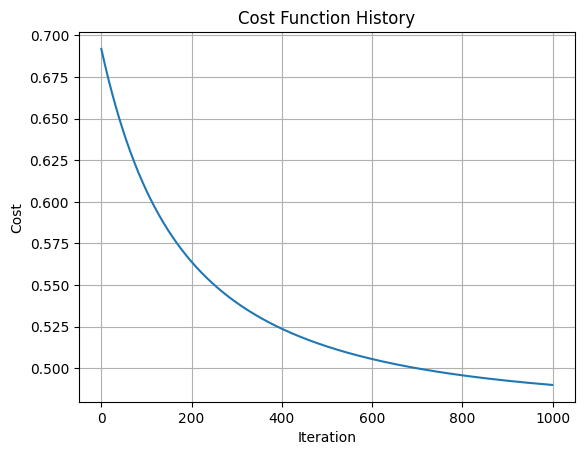

In [28]:
# Get the history of the cost function and plot it
# We call it the learing curve
LogRegModel.plot_learning_curve()

In [29]:
# plot results
LogRegModel.plot_decision_boundary(X_train, Y_train)

ValueError: X_train must have exactly 2 features                                  for 2D plotting.

## Changing the learning rate and the maximum of iteration

In [ ]:
# We can test with a different learning rate and number of iterations
LogRegModel.fit(X_train, Y_train, method='gradient', learning_rate=0.0001, max_iter=5000)

# Predict the coefficients and the bias
coef, bias = LogRegModel.get_params()
print("Coefficients: ", coef)
print("bias: ", bias)

# Metics
metrics(LogRegModel, X_train, Y_train, X_test, Y_test)

Coefficients:  [0.00781836 0.00159858 0.00021689 0.0004903  0.00014363 0.00457166
 0.06445435 0.00204181]
bias:  -0.5425128711020157
Training accuracy:  0.7378472222222222
Testing accuracy:  0.78125
Precision:  0.7121212121212122
Recall:  0.6714285714285714


In [ ]:
# plot results
LogRegModel.plot_decision_boundary(X_train, Y_train)

ValueError: X_train must have exactly 2 features                                  for 2D plotting.

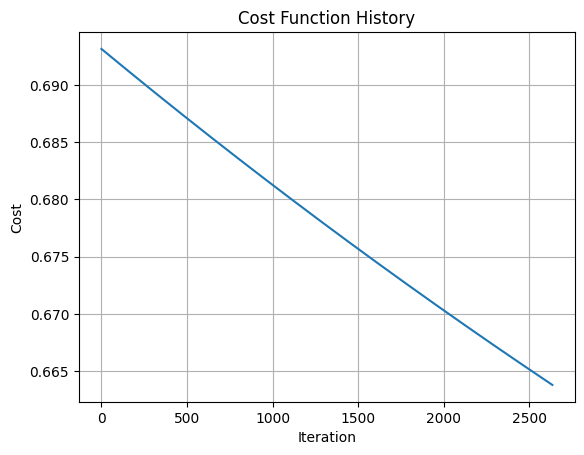

In [ ]:
# Get the history of the cost function and plot it
# We call it the learing curve
cost_history = LogRegModel.get_history()
LogRegModel.plot_learning_curve()

## Without normalising data

In [ ]:
# We test the case of normalise = False
# Note: You might need to adjust the learning rate to a lower value
# since the features are not normalized and can have very different scales

LogRegModel.fit(X_train, Y_train, method='gradient', normalise=False, learning_rate=1e-15, max_iter=5000)

# Predict the coefficients and the bias
Y_pred = LogRegModel.predict(X_train)
coef, bias = LogRegModel.get_params()
print("Coefficients: ", coef)
print("bias: ", bias)
metrics(LogRegModel, X_train, Y_train, X_test, Y_test)

Coefficients:  [-4.87847222e-16 -2.39791667e-14 -2.07343750e-14 -5.40277778e-15
 -8.94097222e-15 -7.60868056e-15 -9.15902778e-17 -8.06423611e-15]
bias:  -3.124999999992946e-16
Training accuracy:  0.65625
Testing accuracy:  0.6354166666666666
Precision:  0.0
Recall:  0.0


In [ ]:
# plot results
LogRegModel.plot_decision_boundary(X_train, Y_train)

ValueError: X_train must have exactly 2 features                                  for 2D plotting.

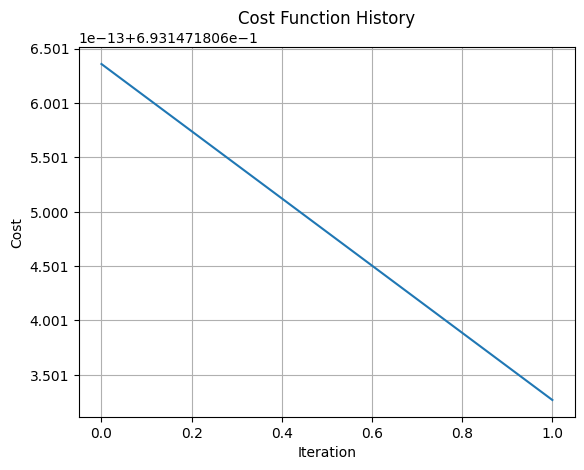

In [ ]:
# Get the history of the cost function and plot it
# We call it the learing curve
cost_history = LogRegModel.get_history()
LogRegModel.plot_learning_curve()

In [ ]:
# We test the case of normalise = False
# With default learning rate and iterations

LogRegModel.fit(X_train, Y_train, method='gradient', normalise=False)

# Predict the coefficients and the bias
coef, bias = LogRegModel.get_params()
print("Coefficients: ", coef)
print("bias: ", bias)

# Metics
metrics(LogRegModel, X_train, Y_train, X_test, Y_test)

Coefficients:  [ 1.52217675 -0.22299849 -1.10717071 -0.24877004 -0.30140369  0.41420931
  0.07887954 -0.24032805]
bias:  -0.32419174201255485
Training accuracy:  0.65625
Testing accuracy:  0.6354166666666666
Precision:  0.0
Recall:  0.0


# Logistic Regression using Scitkit-learn

In [ ]:
from sklearn.linear_model import LogisticRegression

# Fit avec scikit-learn
model = LogisticRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_train)
print("The coefficients :", model.coef_, "The bias:", model.intercept_)

The coefficients : [[ 1.37300106e-01  3.17390634e-02 -9.80034781e-03 -1.94696949e-03
  -8.99991436e-04  9.74779425e-02  9.59088492e-01  4.26237473e-03]] The bias: [-8.16180922]


/home/akef/Documents/ml-from-scratch/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
Y_pred = model.predict(X_test)
print("Testing accuracy with scikit-learn: ", model.score(X_test, Y_test))

from sklearn.metrics import classification_report
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Testing accuracy with scikit-learn:  0.796875

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85       122
           1       0.80      0.59      0.68        70

    accuracy                           0.80       192
   macro avg       0.80      0.75      0.76       192
weighted avg       0.80      0.80      0.79       192

